In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/creditcard.csv")

df.shape

(284807, 31)

In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [4]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [5]:
df["Class"].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

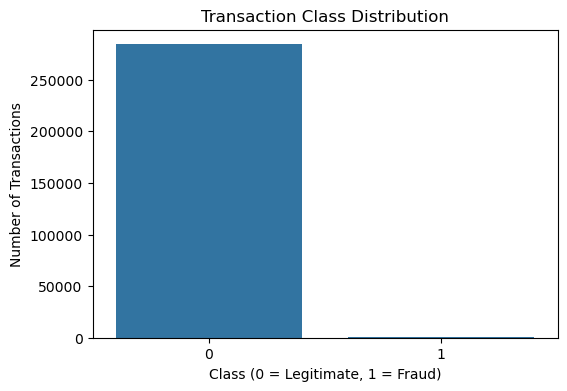

In [6]:
plt.figure(figsize=(6, 4))

sns.countplot(x="Class", data=df)

plt.title("Transaction Class Distribution")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")

plt.show()

In [8]:
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


In [9]:
df.groupby("Class")["Time"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,94838.202258,47484.015786,0.0,54230.0,84711.0,139333.0,172792.0
1,492.0,80746.806911,47835.365138,406.0,41241.5,75568.5,128483.0,170348.0


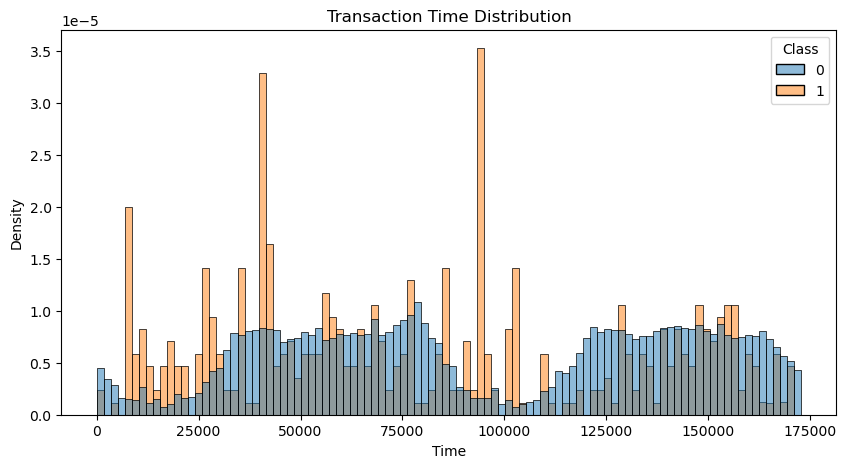

In [10]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    stat="density",
    common_norm=False
)

plt.title("Transaction Time Distribution")
plt.show()

In [11]:
df["Hour"] = df["Time"] / 3600

In [12]:
df.groupby("Class")["Hour"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,26.343945,13.190004,0.000000,15.063889,23.530833,38.703611,47.997778
1,492.0,22.429669,13.287601,0.112778,11.455972,20.991250,35.689722,47.318889


In [13]:
fraud_means = df.groupby("Class")[
    [f"V{i}" for i in range(1, 29)]
].mean().T

fraud_means.columns = ["Legitimate", "Fraud"]

fraud_means["Difference"] = (
    fraud_means["Fraud"] - fraud_means["Legitimate"]
)

fraud_means.sort_values(
    "Difference",
    key=abs,
    ascending=False
).head(10)

,Legitimate,Fraud,Difference
V3,0.012171,-7.033281,-7.045452
V14,0.012064,-6.971723,-6.983787
V17,0.011535,-6.665836,-6.677371
V12,0.010832,-6.259393,-6.270225
V10,0.009824,-5.676883,-5.686707
V7,0.009637,-5.568731,-5.578368
V1,0.008258,-4.771948,-4.780206
V4,-0.007860,4.542029,4.549889
V16,0.007164,-4.139946,-4.147110
V11,-0.006576,3.800173,3.806749


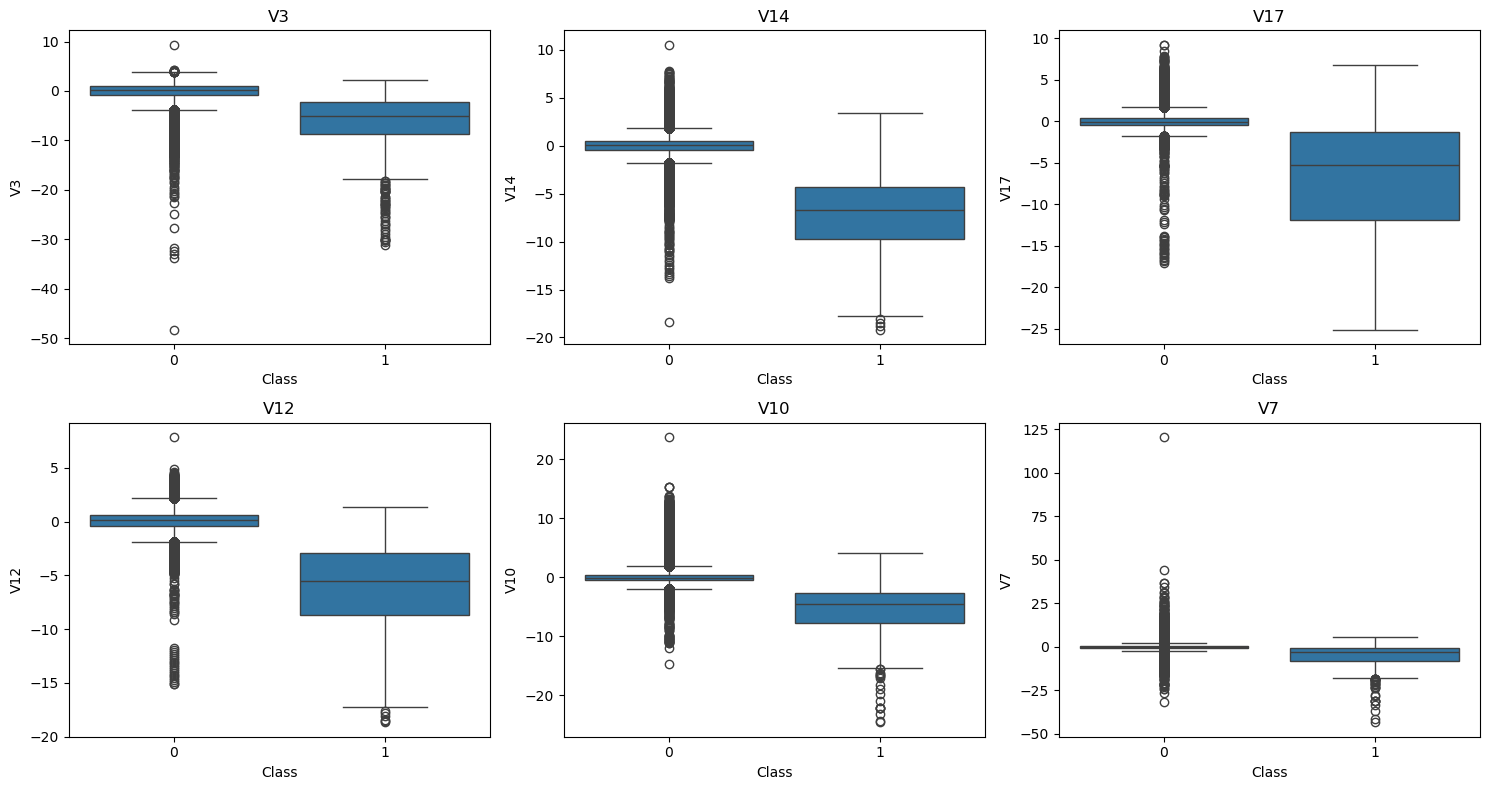

In [14]:
top_features = ["V3", "V14", "V17", "V12", "V10", "V7"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, feature in zip(axes.ravel(), top_features):
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )
    ax.set_title(feature)

plt.tight_layout()
plt.show()

In [15]:
df.isnull().sum().sum()

np.int64(0)

In [18]:
df = df.drop_duplicates().reset_index(drop=True)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [22]:
X = X.drop("Hour", axis=1, errors="ignore")

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [24]:
print("Training:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTesting:")
print(y_test.value_counts(normalize=True) * 100)

Training:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [25]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [26]:
y_pred = model.predict(X_test)

In [29]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56643     8]
 [   40    55]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.87      0.58      0.70        95

    accuracy                           1.00     56746
   macro avg       0.94      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



In [31]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:,1]
print("ROC-AUC: ", roc_auc_score(y_test, y_prob))

ROC-AUC:  0.9363924453416997


In [32]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

for threshold in thresholds:
    y_pred_threshold = (y_prob >= threshold).astype(int)

    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold: 0.1 | Precision: 0.722 | Recall: 0.684 | F1: 0.703
Threshold: 0.2 | Precision: 0.808 | Recall: 0.663 | F1: 0.728
Threshold: 0.3 | Precision: 0.853 | Recall: 0.611 | F1: 0.712
Threshold: 0.4 | Precision: 0.875 | Recall: 0.589 | F1: 0.704
Threshold: 0.5 | Precision: 0.873 | Recall: 0.579 | F1: 0.696


In [33]:
balanced_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train, y_train)

c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [34]:
y_pred_balanced = balanced_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_balanced))

print(classification_report(y_test, y_pred_balanced))

[[55138  1513]
 [   12    83]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746



In [35]:
y_prob_balanced = balanced_model.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_balanced)
)

ROC-AUC: 0.9600173360622611


In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE( random_state = 42 )
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [39]:
print(y_train_smote.value_counts())

Class
0    226602
1    226602
Name: count, dtype: int64


In [40]:
smote_model = LogisticRegression(
    max_iter=1000
)

smote_model.fit(
    X_train_smote,
    y_train_smote
)

c:\Users\ZoRo\anaconda3\envs\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred_smote = smote_model.predict(X_test)

print(confusion_matrix(y_test, y_pred_smote))

print(classification_report(y_test, y_pred_smote))

[[56116   535]
 [   14    81]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     56651
           1       0.13      0.85      0.23        95

    accuracy                           0.99     56746
   macro avg       0.57      0.92      0.61     56746
weighted avg       1.00      0.99      0.99     56746



In [42]:
y_prob_smote = smote_model.predict_proba(X_test)[:, 1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob_smote)
)

ROC-AUC: 0.9559869338488938


In [43]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = np.arange(0.05, 0.96, 0.05)

results = []

for threshold in thresholds:
    y_pred = (y_prob_smote >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(results)

threshold_df

,Threshold,Precision,Recall,F1
0,0.05,0.013121,0.926316,0.025875
1,0.10,0.023060,0.894737,0.044962
2,0.15,0.034170,0.873684,0.065769
3,0.20,0.047267,0.873684,0.089681
4,0.25,0.059117,0.873684,0.110740
5,0.30,0.070873,0.863158,0.130990
6,0.35,0.082000,0.863158,0.149772
7,0.40,0.093859,0.852632,0.169102
8,0.45,0.110354,0.852632,0.195416
9,0.50,0.131494,0.852632,0.227848


In [44]:
threshold_df.loc[
    threshold_df["F1"].idxmax()
]

Threshold    0.950000
Precision    0.590551
Recall       0.789474
F1           0.675676
Name: 18, dtype: float64

In [45]:
threshold_df[
    threshold_df["Recall"] >= 0.80
].sort_values(
    "Precision",
    ascending=False
).head()

,Threshold,Precision,Recall,F1
15,0.80,0.301961,0.810526,0.440000
14,0.75,0.258065,0.842105,0.395062
13,0.70,0.229885,0.842105,0.361174
12,0.65,0.200495,0.852632,0.324649
11,0.60,0.172708,0.852632,0.287234


In [46]:
thresholds = np.arange(0.90, 1.001, 0.01)

results = []

for threshold in thresholds:
    y_pred = (y_prob_smote >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

fine_threshold_df = pd.DataFrame(results)

fine_threshold_df.loc[
    fine_threshold_df["F1"].idxmax()
]

Threshold    0.990000
Precision    0.732673
Recall       0.778947
F1           0.755102
Name: 9, dtype: float64

In [48]:
final_threshold = 0.99

y_pred_final = (
    y_prob_smote >= final_threshold
).astype(int)

print(confusion_matrix(y_test, y_pred_final))

print(
    classification_report(
        y_test,
        y_pred_final
    )
)

[[56624    27]
 [   21    74]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.73      0.78      0.76        95

    accuracy                           1.00     56746
   macro avg       0.87      0.89      0.88     56746
weighted avg       1.00      1.00      1.00     56746

